In [15]:
try:
    dataset
except NameError:
    print("Run the data pipeline first!")

Run the data pipeline first!


In [16]:
print("dataset" in globals())

False


In [17]:
import matplotlib.pyplot as plt

category_counts = {
    col: dataset[col].sum()
    for col in dataset.columns
    if col.startswith("person_") or col.startswith("context_")
}

category_counts = pd.Series(category_counts).sort_values()

# Plot
category_counts.plot(kind="barh")
plt.title("Category Counts")
plt.xlabel("Count")
plt.show()

NameError: name 'dataset' is not defined

In [29]:
NEG_THRESHOLD = -0.05

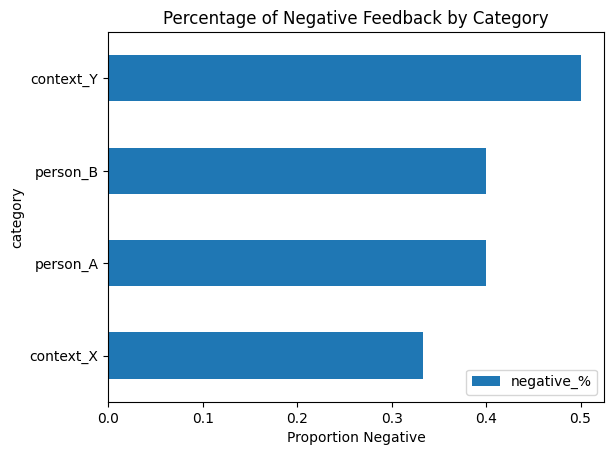

In [30]:
neg_stats = []

for col in dataset.columns:
  if col.startswith("person_") or col.startswith("context_"):
    subset = dataset[dataset[col] == 1]

    if len(subset) == 0:
      continue

    neg_percent = (subset["overall_sentiment"] < NEG_THRESHOLD).mean()

    neg_stats.append({
      "category": col,
      "negative_%": neg_percent
    })

neg_df = pd.DataFrame(neg_stats).sort_values("negative_%")

# Plot
neg_df.plot(kind="barh", x="category", y="negative_%")
plt.title("Percentage of Negative Feedback by Category")
plt.xlabel("Proportion Negative")
plt.show()

In [31]:
NEG_THRESHOLD = -0.05

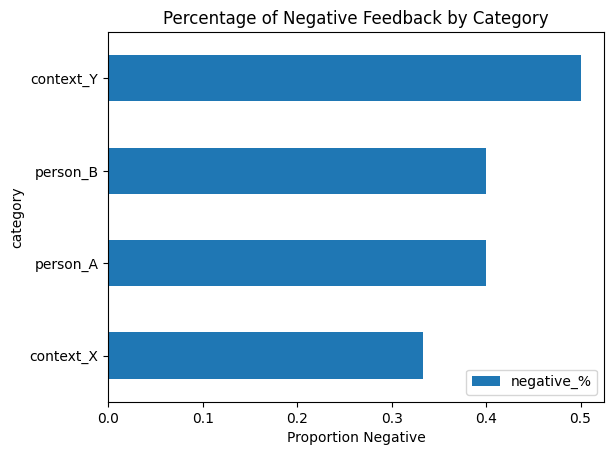

In [32]:
neg_stats = []

for col in dataset.columns:
  if col.startswith("person_") or col.startswith("context_"):
    subset = dataset[dataset[col] == 1]

    if len(subset) == 0:
      continue

    neg_percent = (subset["overall_sentiment"] < NEG_THRESHOLD).mean()

    neg_stats.append({
      "category": col,
      "negative_%": neg_percent
    })

neg_df = pd.DataFrame(neg_stats).sort_values("negative_%")

# Plot
neg_df.plot(kind="barh", x="category", y="negative_%")
plt.title("Percentage of Negative Feedback by Category")
plt.xlabel("Proportion Negative")
plt.show()

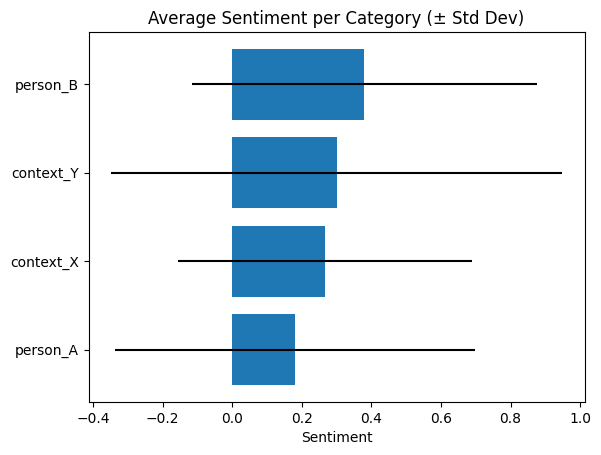

In [27]:
stats = []

for col in dataset.columns:
    if col.startswith("person_") or col.startswith("context_"):
        subset = dataset[dataset[col] == 1]["overall_sentiment"]

        stats.append({
            "category": col,
            "mean": subset.mean(),
            "std": subset.std()
        })

stats_df = pd.DataFrame(stats).sort_values("mean")

# Plot with error bars
plt.barh(stats_df["category"], stats_df["mean"], xerr=stats_df["std"])
plt.title("Average Sentiment per Category (± Std Dev)")
plt.xlabel("Sentiment")
plt.show()

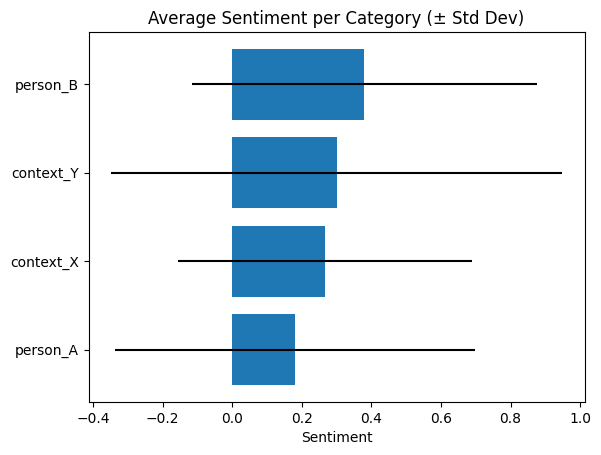

In [28]:
stats = []

for col in dataset.columns:
    if col.startswith("person_") or col.startswith("context_"):
        subset = dataset[dataset[col] == 1]["overall_sentiment"]

        stats.append({
            "category": col,
            "mean": subset.mean(),
            "std": subset.std()
        })

stats_df = pd.DataFrame(stats).sort_values("mean")

# Plot with error bars
plt.barh(stats_df["category"], stats_df["mean"], xerr=stats_df["std"])
plt.title("Average Sentiment per Category (± Std Dev)")
plt.xlabel("Sentiment")
plt.show()

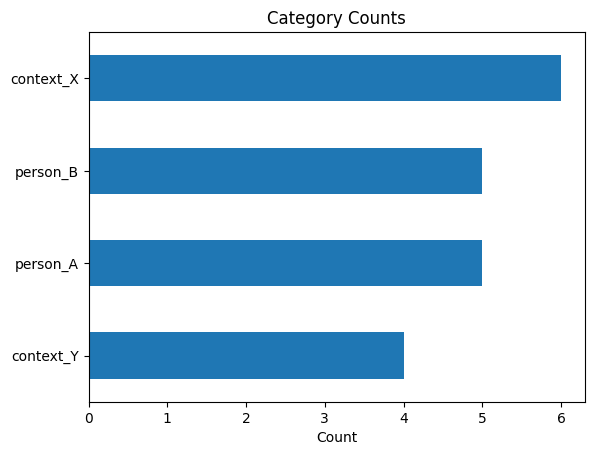

In [25]:
import matplotlib.pyplot as plt

category_counts = {
    col: dataset[col].sum()
    for col in dataset.columns
    if col.startswith("person_") or col.startswith("context_")
}

category_counts = pd.Series(category_counts).sort_values()

# Plot
category_counts.plot(kind="barh")
plt.title("Category Counts")
plt.xlabel("Count")
plt.show()

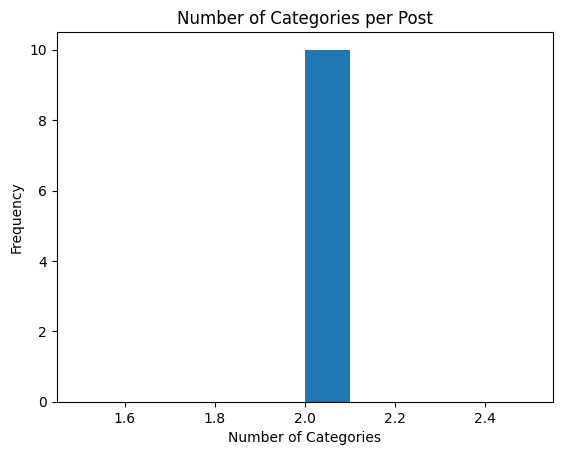

In [26]:
# Count number of active categories per post
dataset["num_categories"] = dataset[
    [c for c in dataset.columns if c.startswith("person_") or c.startswith("context_")]
].sum(axis=1)

# Plot
dataset["num_categories"].plot(kind="hist", bins=10)
plt.title("Number of Categories per Post")
plt.xlabel("Number of Categories")
plt.show()

In [23]:
# Generate dummy data for post_sentiment
dummy_post_sentiment = pd.DataFrame({
    'post_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'overall_sentiment': [0.5, -0.2, 0.8, -0.1, 0.3, 0.6, -0.4, 0.9, -0.3, 0.7]
})

# Generate dummy data for meta with person_ and context_ categories
dummy_meta = pd.DataFrame({
    'post_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'person_A': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    'person_B': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    'context_X': [1, 1, 0, 0, 1, 1, 0, 0, 1, 1],
    'context_Y': [0, 0, 1, 1, 0, 0, 1, 1, 0, 0]
})

post_sentiment = dummy_post_sentiment
meta = dummy_meta

print("Dummy data generated for 'post_sentiment' and 'meta'.")

Dummy data generated for 'post_sentiment' and 'meta'.


In [24]:
dataset = post_sentiment.merge(meta, on="post_id")
display(dataset.head())

,post_id,overall_sentiment,person_A,person_B,context_X,context_Y
0,1,0.5,1,0,1,0
1,2,-0.2,0,1,1,0
2,3,0.8,1,0,0,1
3,4,-0.1,0,1,0,1
4,5,0.3,1,0,1,0


In [21]:
import matplotlib.pyplot as plt

category_counts = {
    col: dataset[col].sum()
    for col in dataset.columns
    if col.startswith("person_") or col.startswith("context_")
}

category_counts = pd.Series(category_counts).sort_values()

# Plot
category_counts.plot(kind="barh")
plt.title("Category Counts")
plt.xlabel("Count")
plt.show()

TypeError: no numeric data to plot

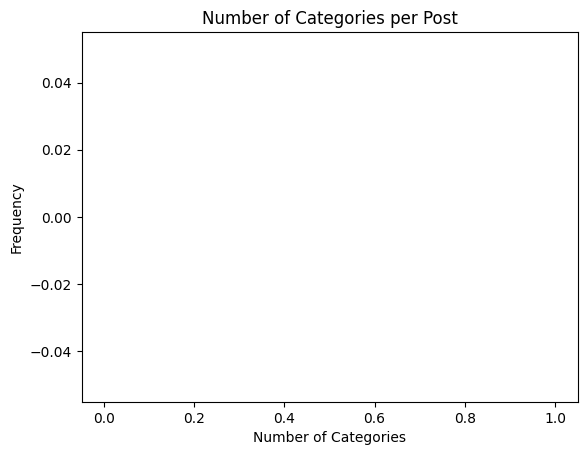

In [22]:
# Count number of active categories per post
dataset["num_categories"] = dataset[
    [c for c in dataset.columns if c.startswith("person_") or c.startswith("context_")]
].sum(axis=1)

# Plot
dataset["num_categories"].plot(kind="hist", bins=10)
plt.title("Number of Categories per Post")
plt.xlabel("Number of Categories")
plt.show()

In [18]:
import pandas as pd

In [19]:
# Placeholder: Assuming post_sentiment is loaded from a CSV file
# Replace 'post_sentiment.csv' with the actual path to your file
try:
    post_sentiment = pd.read_csv('post_sentiment.csv')
except FileNotFoundError:
    print("Warning: 'post_sentiment.csv' not found. Creating an empty DataFrame.")
    post_sentiment = pd.DataFrame({'post_id': [], 'overall_sentiment': []})

# Placeholder: Assuming meta is loaded from a CSV file
# Replace 'meta.csv' with the actual path to your file
try:
    meta = pd.read_csv('meta.csv')
except FileNotFoundError:
    print("Warning: 'meta.csv' not found. Creating an empty DataFrame.")
    meta = pd.DataFrame({'post_id': []})

Now that `post_sentiment` and `meta` are defined (even with placeholder data), you can run the cell that creates `dataset`:

In [20]:
dataset = post_sentiment.merge(meta, on="post_id")
display(dataset.head())

,post_id,overall_sentiment


In [ ]:
# Count number of active categories per post
dataset["num_categories"] = dataset[
    [c for c in dataset.columns if c.startswith("person_") or c.startswith("context_")]
].sum(axis=1)

# Plot
dataset["num_categories"].plot(kind="hist", bins=10)
plt.title("Number of Categories per Post")
plt.xlabel("Number of Categories")
plt.show()

In [ ]:
stats = []

for col in dataset.columns:
    if col.startswith("person_") or col.startswith("context_"):
        subset = dataset[dataset[col] == 1]["overall_sentiment"]

        stats.append({
            "category": col,
            "mean": subset.mean(),
            "std": subset.std()
        })

stats_df = pd.DataFrame(stats).sort_values("mean")

# Plot with error bars
plt.barh(stats_df["category"], stats_df["mean"], xerr=stats_df["std"])
plt.title("Average Sentiment per Category (± Std Dev)")
plt.xlabel("Sentiment")
plt.show()

In [ ]:
NEG_THRESHOLD = -0.05

In [ ]:
neg_stats = []

for col in dataset.columns:
  if col.startswith("person_") or col.startswith("context_"):
    subset = dataset[dataset[col] == 1]

    if len(subset) == 0:
      continue

    neg_percent = (subset["overall_sentiment"] < NEG_THRESHOLD).mean()

    neg_stats.append({
      "category": col,
      "negative_%": neg_percent
    })

neg_df = pd.DataFrame(neg_stats).sort_values("negative_%")

# Plot
neg_df.plot(kind="barh", x="category", y="negative_%")
plt.title("Percentage of Negative Feedback by Category")
plt.xlabel("Proportion Negative")
plt.show()

In [ ]:
dataset = post_sentiment.merge(meta,on="post_id")